In [14]:
from pathlib import Path
import pandas as pd
import numpy as np

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
TRAINING_DIR = DATA_DIR / "training"

df = pd.read_csv(
    TRAINING_DIR / "candidate_job_features.csv"
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (5000, 16)
   candidate_experience_years  candidate_skill_count  \
0                           2                      5   
1                           5                      9   
2                           1                      6   
3                          12                     10   
4                           3                      4   

   expected_experience_years  experience_gap  experience_fit  job_skill_count  \
0                          5              -3        0.500000                6   
1                          5               0        1.000000               14   
2                          1               0        1.000000               11   
3                          8               4        0.555556               28   
4                          5              -2        0.666667               19   

   matched_skill_count  job_skill_coverage  candidate_skill_coverage  \
0                    0            0.000000                  0.000000   
1     

In [15]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
df.isna().sum()

Rows: 5000
Columns: 16

Columns:
['candidate_experience_years', 'candidate_skill_count', 'expected_experience_years', 'experience_gap', 'experience_fit', 'job_skill_count', 'matched_skill_count', 'job_skill_coverage', 'candidate_skill_coverage', 'role_match_score', 'job_remote_hint', 'semantic_similarity', 'match_label', 'pair_id', 'candidate_id', 'job_id']

Missing values:


candidate_experience_years    0
candidate_skill_count         0
expected_experience_years     0
experience_gap                0
experience_fit                0
job_skill_count               0
matched_skill_count           0
job_skill_coverage            0
candidate_skill_coverage      0
role_match_score              0
job_remote_hint               0
semantic_similarity           0
match_label                   0
pair_id                       0
candidate_id                  0
job_id                        0
dtype: int64

In [16]:
print("Match label distribution:")
print(df["match_label"].value_counts())

print("\nPercentage:")
print(
    df["match_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Match label distribution:
match_label
0    3500
1    1500
Name: count, dtype: int64

Percentage:
match_label
0    70.0
1    30.0
Name: proportion, dtype: float64


In [17]:
feature_columns = [
    "candidate_experience_years",
    "candidate_skill_count",
    "expected_experience_years",
    "experience_gap",
    "experience_fit",
    "job_skill_count",
    "matched_skill_count",
    "job_skill_coverage",
    "candidate_skill_coverage",
    "role_match_score",
    "job_remote_hint",
    "semantic_similarity"
]

df[feature_columns].describe()

,candidate_experience_years,candidate_skill_count,expected_experience_years,experience_gap,experience_fit,job_skill_count,matched_skill_count,job_skill_coverage,candidate_skill_coverage,role_match_score,semantic_similarity
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.015600,7.159200,2.360600,3.655000,0.245186,16.195600,1.099800,0.067687,0.158477,0.137720,0.393404
std,3.762152,1.757178,2.638477,4.588964,0.353893,7.340308,1.474678,0.088384,0.211331,0.231243,0.131313
min,0.000000,2.000000,0.000000,-9.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.013743
25%,3.000000,6.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.298504
50%,5.000000,7.000000,2.000000,3.000000,0.000000,16.000000,1.000000,0.038462,0.111111,0.000000,0.380684
75%,8.000000,9.000000,5.000000,7.000000,0.500000,21.000000,2.000000,0.111111,0.250000,0.250000,0.473856
max,20.000000,10.000000,10.000000,20.000000,1.000000,46.000000,9.000000,0.583333,1.000000,1.000000,0.771311


In [18]:
df.groupby("match_label")[feature_columns].mean().T

match_label,0,1
candidate_experience_years,6.018000,6.010000
candidate_skill_count,7.020000,7.484000
expected_experience_years,2.334286,2.422000
experience_gap,3.683714,3.588000
experience_fit,0.240872,0.255253
job_skill_count,16.270571,16.020667
matched_skill_count,0.574857,2.324667
job_skill_coverage,0.035840,0.141995
candidate_skill_coverage,0.087481,0.324135
role_match_score,0.079554,0.273441


In [19]:
correlation = df[feature_columns].corr()

print(correlation.round(2))

                            candidate_experience_years  candidate_skill_count  \
candidate_experience_years                        1.00                   0.42   
candidate_skill_count                             0.42                   1.00   
expected_experience_years                         0.00                  -0.02   
experience_gap                                    0.82                   0.36   
experience_fit                                   -0.27                  -0.14   
job_skill_count                                   0.02                   0.02   
matched_skill_count                               0.02                   0.23   
job_skill_coverage                               -0.00                   0.22   
candidate_skill_coverage                         -0.08                  -0.09   
role_match_score                                 -0.03                   0.03   
job_remote_hint                                   0.02                   0.02   
semantic_similarity         

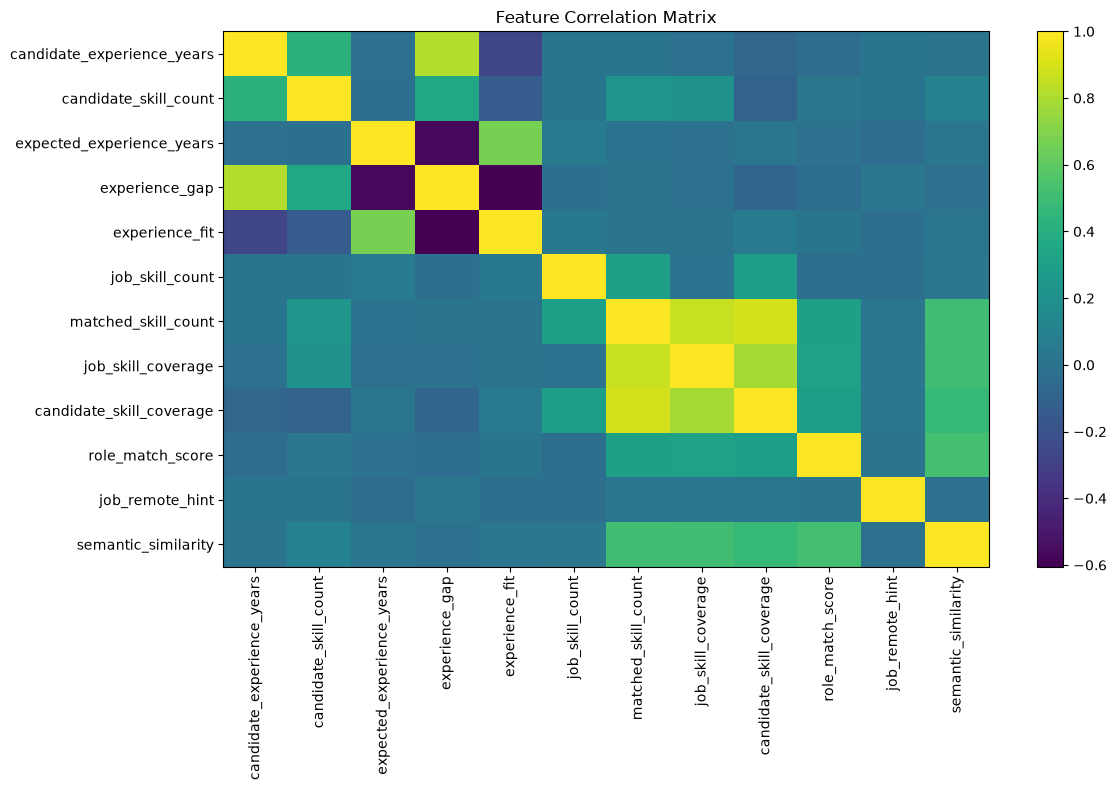

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar()

plt.title("Feature Correlation Matrix")
plt.tight_layout()

plt.show()

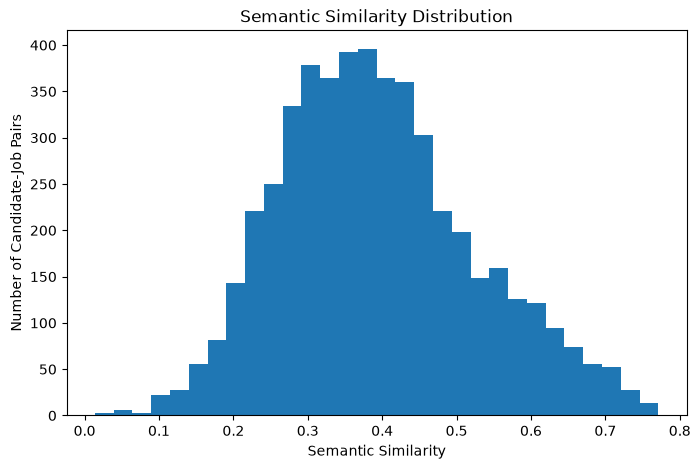

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["semantic_similarity"],
    bins=30
)

plt.xlabel("Semantic Similarity")
plt.ylabel("Number of Candidate-Job Pairs")
plt.title("Semantic Similarity Distribution")

plt.show()

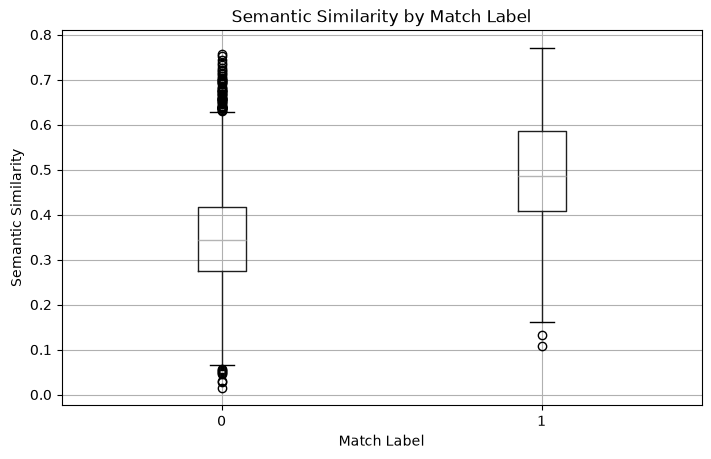

In [22]:
df.boxplot(
    column="semantic_similarity",
    by="match_label",
    figsize=(8, 5)
)

plt.title("Semantic Similarity by Match Label")
plt.suptitle("")
plt.xlabel("Match Label")
plt.ylabel("Semantic Similarity")

plt.show()

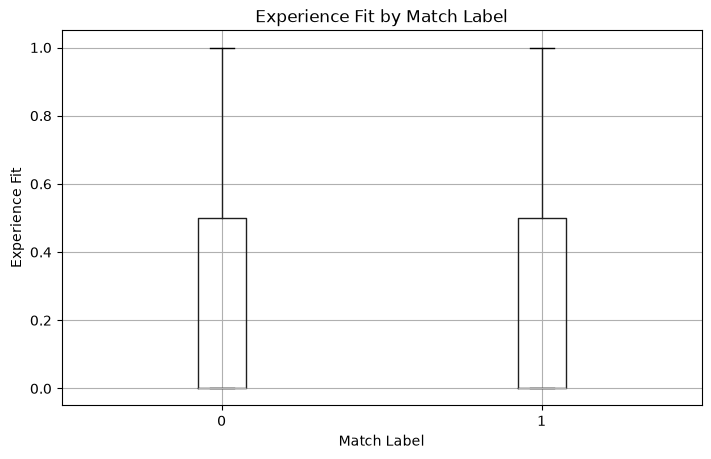

In [23]:
df.boxplot(
    column="experience_fit",
    by="match_label",
    figsize=(8, 5)
)

plt.title("Experience Fit by Match Label")
plt.suptitle("")
plt.xlabel("Match Label")
plt.ylabel("Experience Fit")

plt.show()

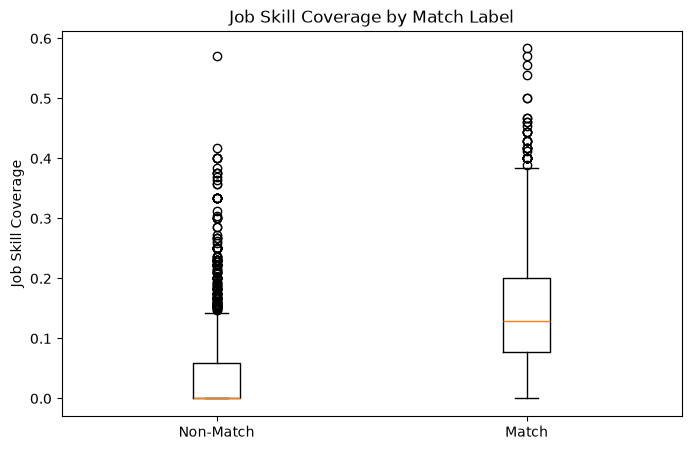

In [24]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["match_label"] == 0]["job_skill_coverage"],
        df[df["match_label"] == 1]["job_skill_coverage"]
    ],
    tick_labels=["Non-Match", "Match"]
)

plt.ylabel("Job Skill Coverage")
plt.title("Job Skill Coverage by Match Label")

plt.show()

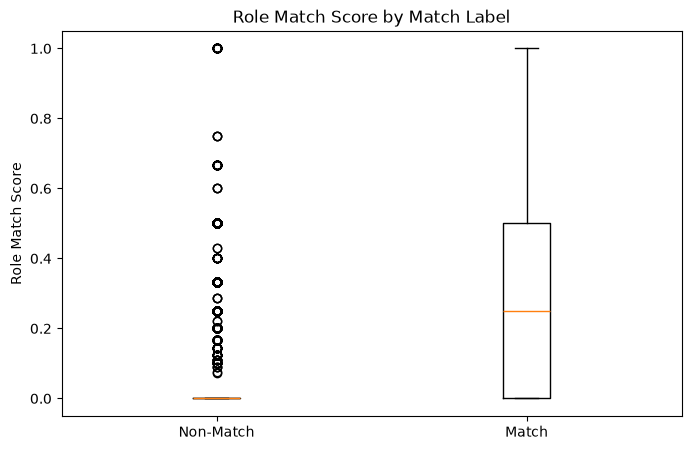

In [25]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["match_label"] == 0]["role_match_score"],
        df[df["match_label"] == 1]["role_match_score"]
    ],
    tick_labels=["Non-Match", "Match"]
)

plt.ylabel("Role Match Score")
plt.title("Role Match Score by Match Label")

plt.show()

In [26]:
print("EDA SUMMARY")
print("Dataset shape:", df.shape)

print("\nMatch distribution:")
print(df["match_label"].value_counts())

print("\nAverage features by match label:")
print(
    df.groupby("match_label")[feature_columns]
    .mean()
    .round(3)
)

EDA SUMMARY
Dataset shape: (5000, 16)

Match distribution:
match_label
0    3500
1    1500
Name: count, dtype: int64

Average features by match label:
             candidate_experience_years  candidate_skill_count  \
match_label                                                      
0                                 6.018                  7.020   
1                                 6.010                  7.484   

             expected_experience_years  experience_gap  experience_fit  \
match_label                                                              
0                                2.334           3.684           0.241   
1                                2.422           3.588           0.255   

             job_skill_count  matched_skill_count  job_skill_coverage  \
match_label                                                             
0                     16.271                0.575               0.036   
1                     16.021                2.325               0.14